# Support Vector Machine

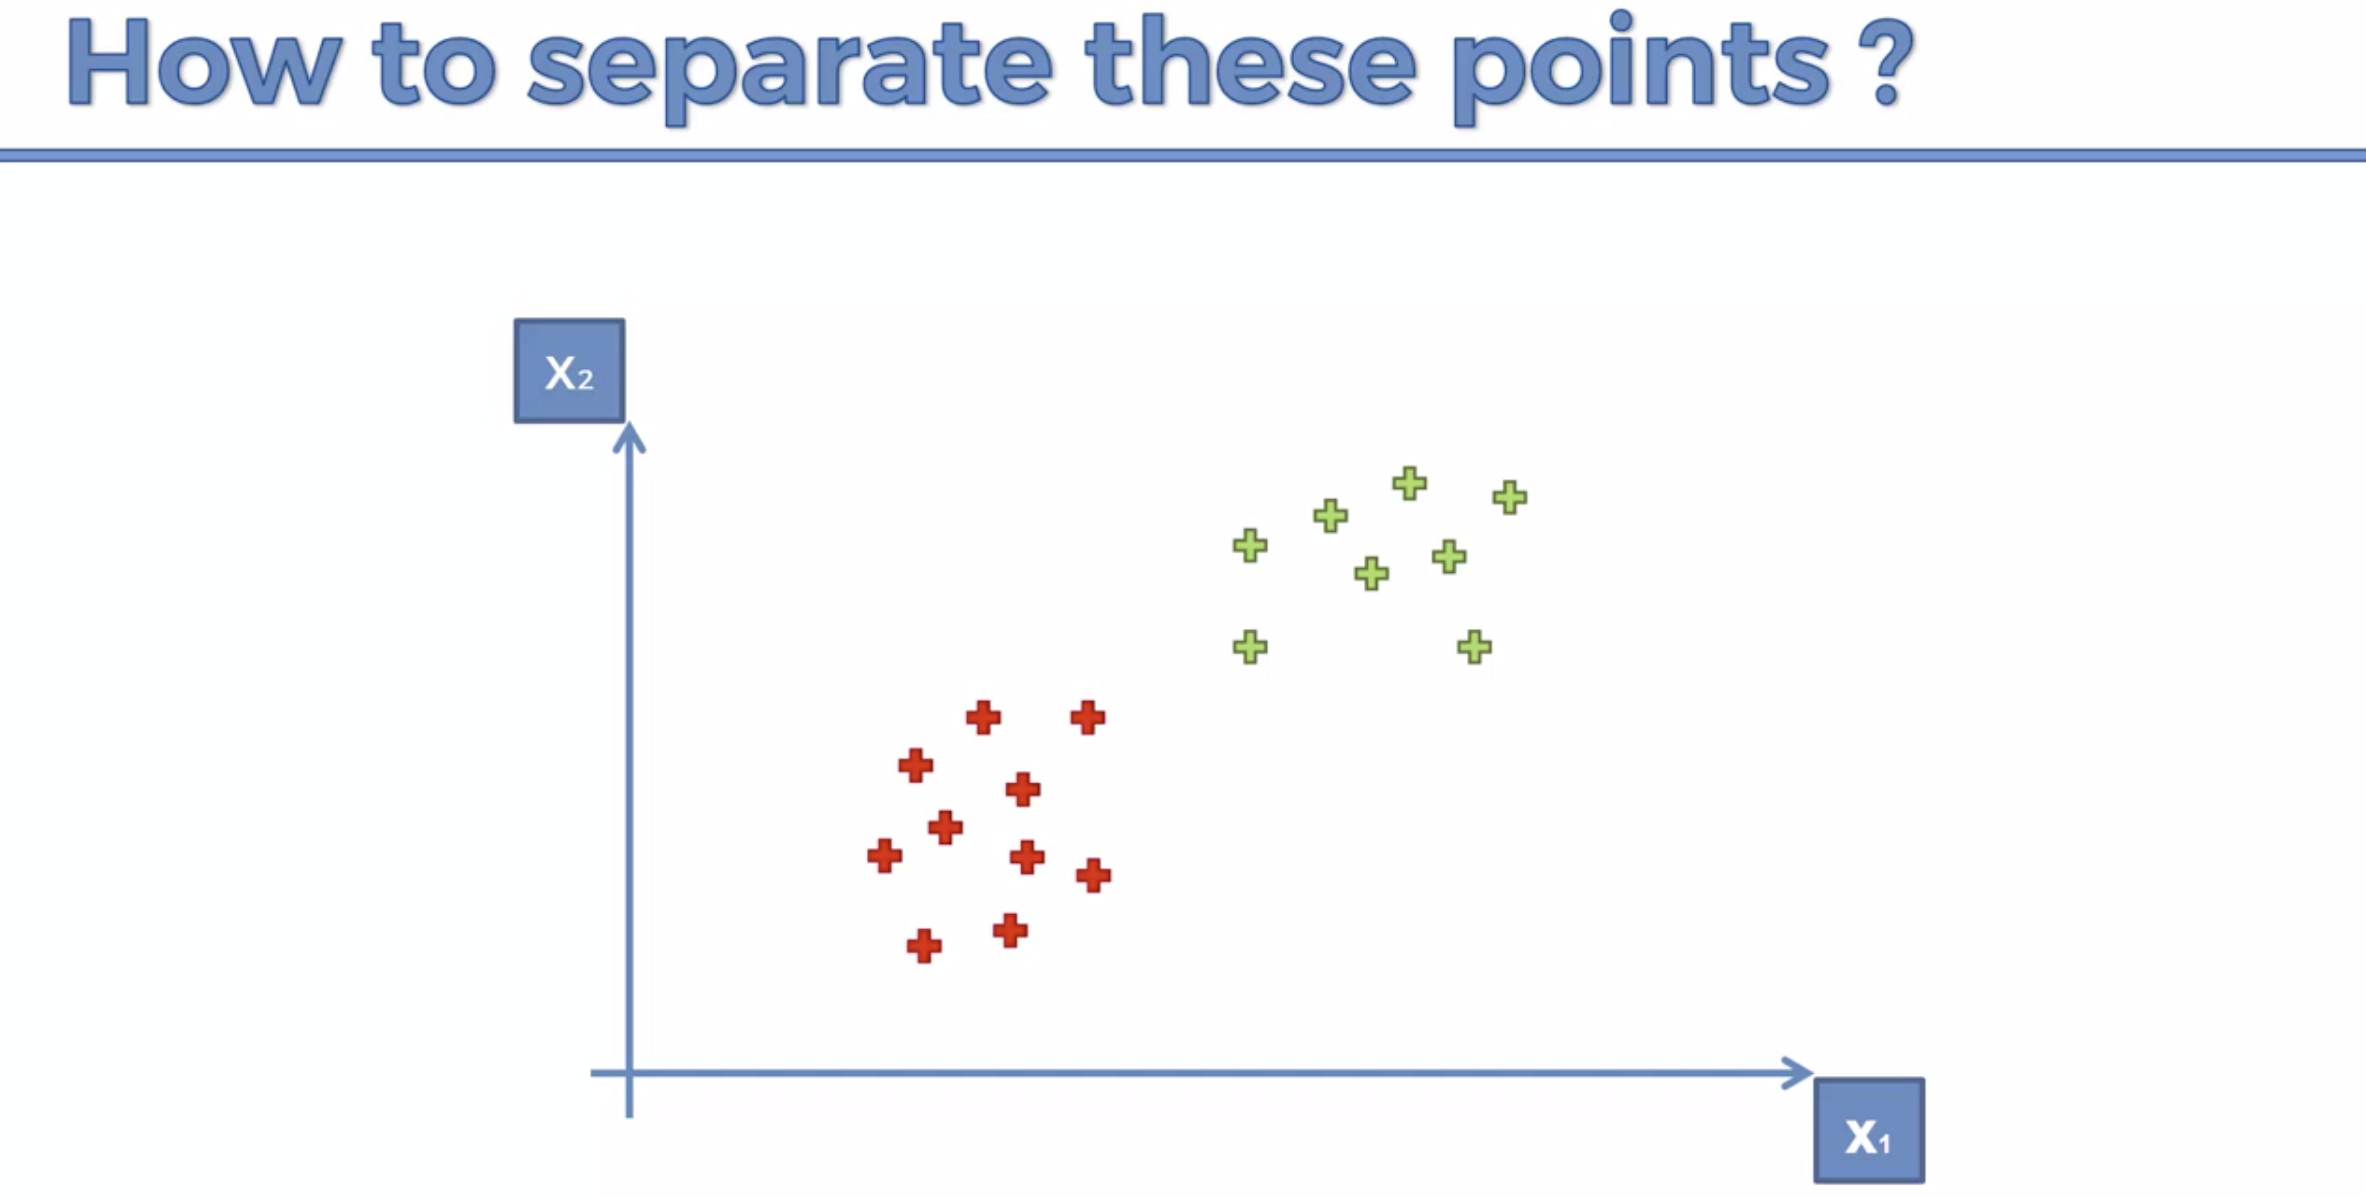

## 아래의 3개 의 선 모두, 분류하는 선이 모두 맞다. 그러면 어떤것이 더 정확할까?

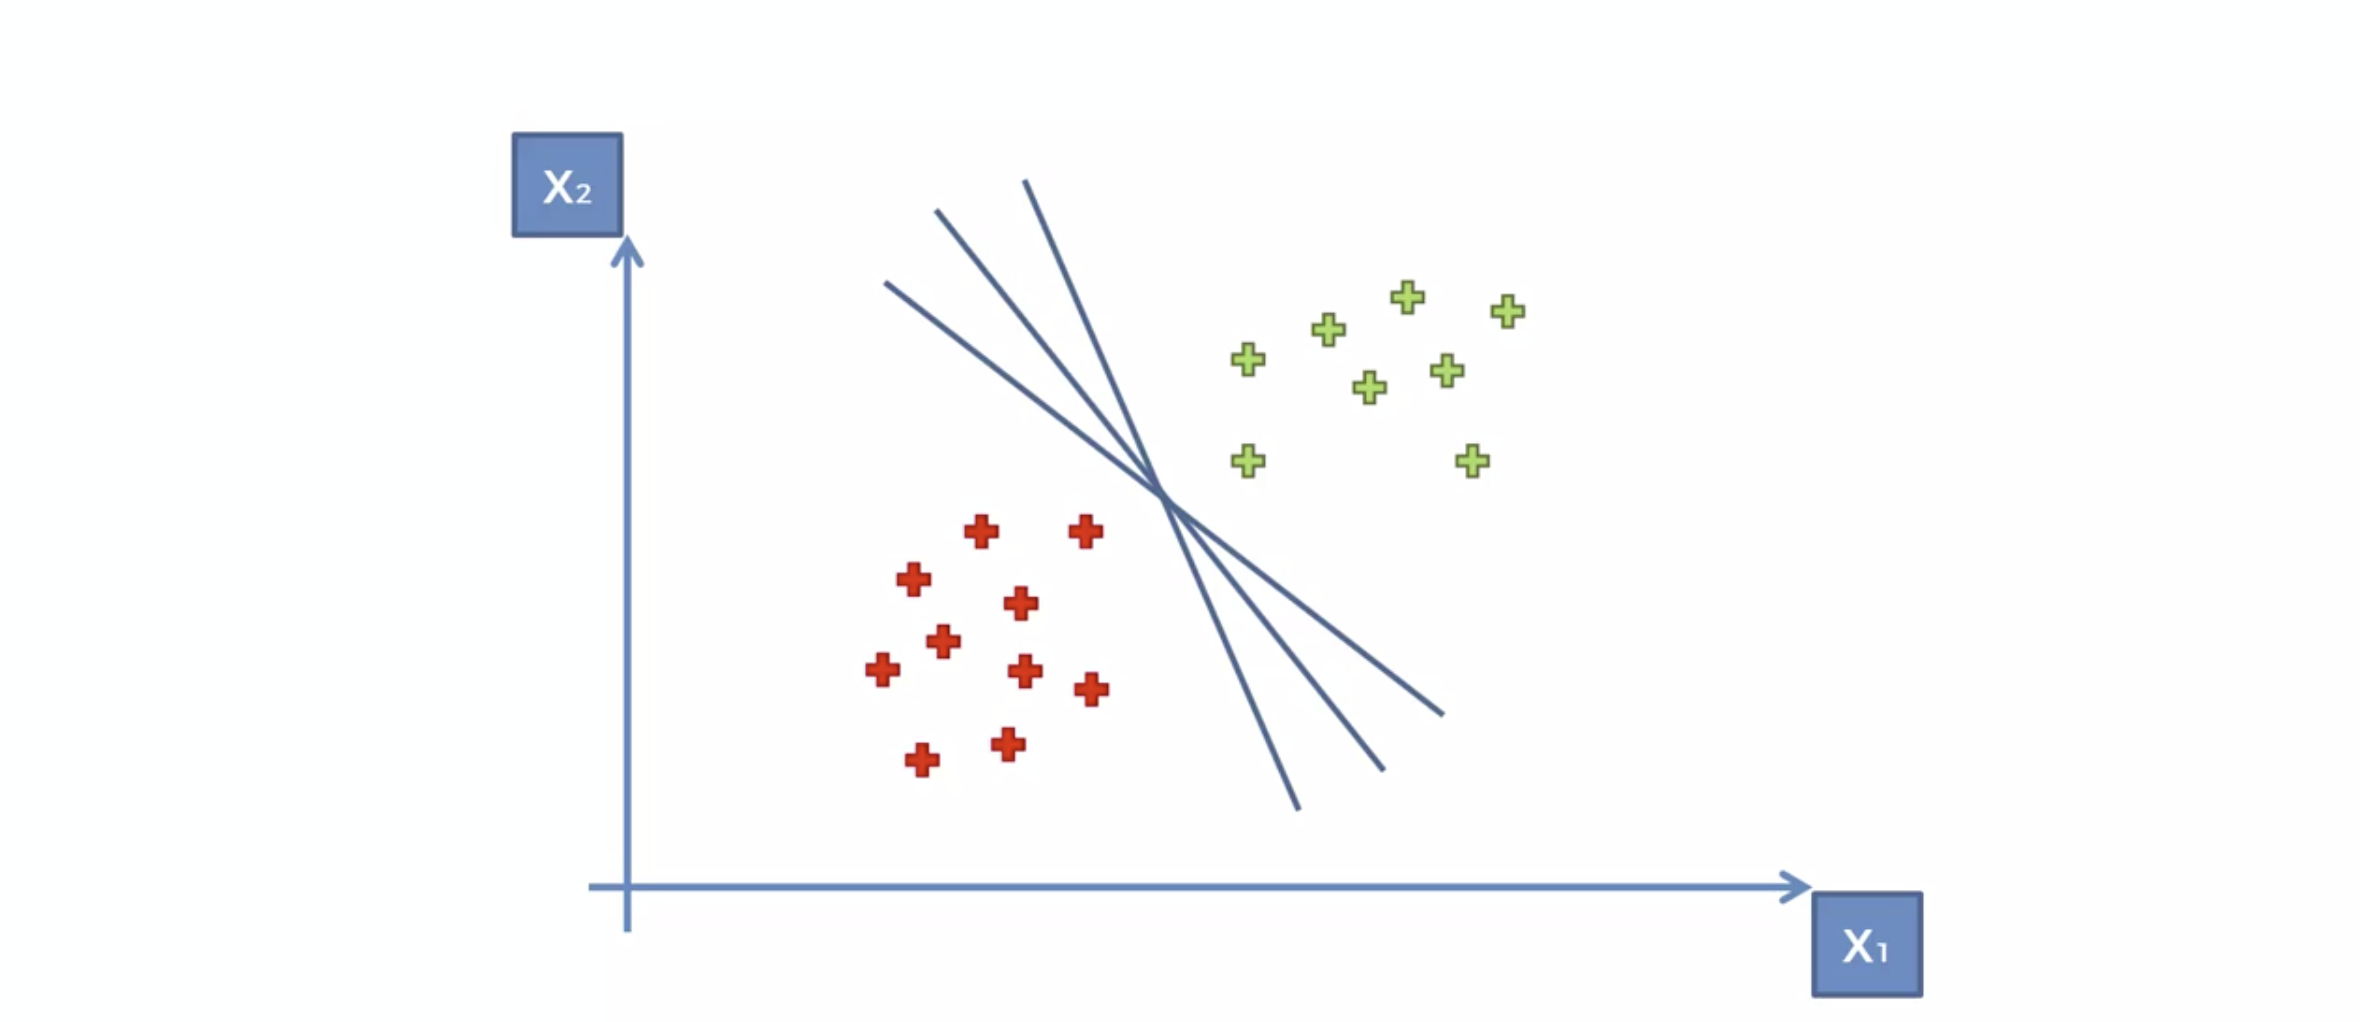

## 분류선에 가장 가까운 데이터들을, 가장 큰 마진(margin)으로 설정하는 선으로 결정하자.

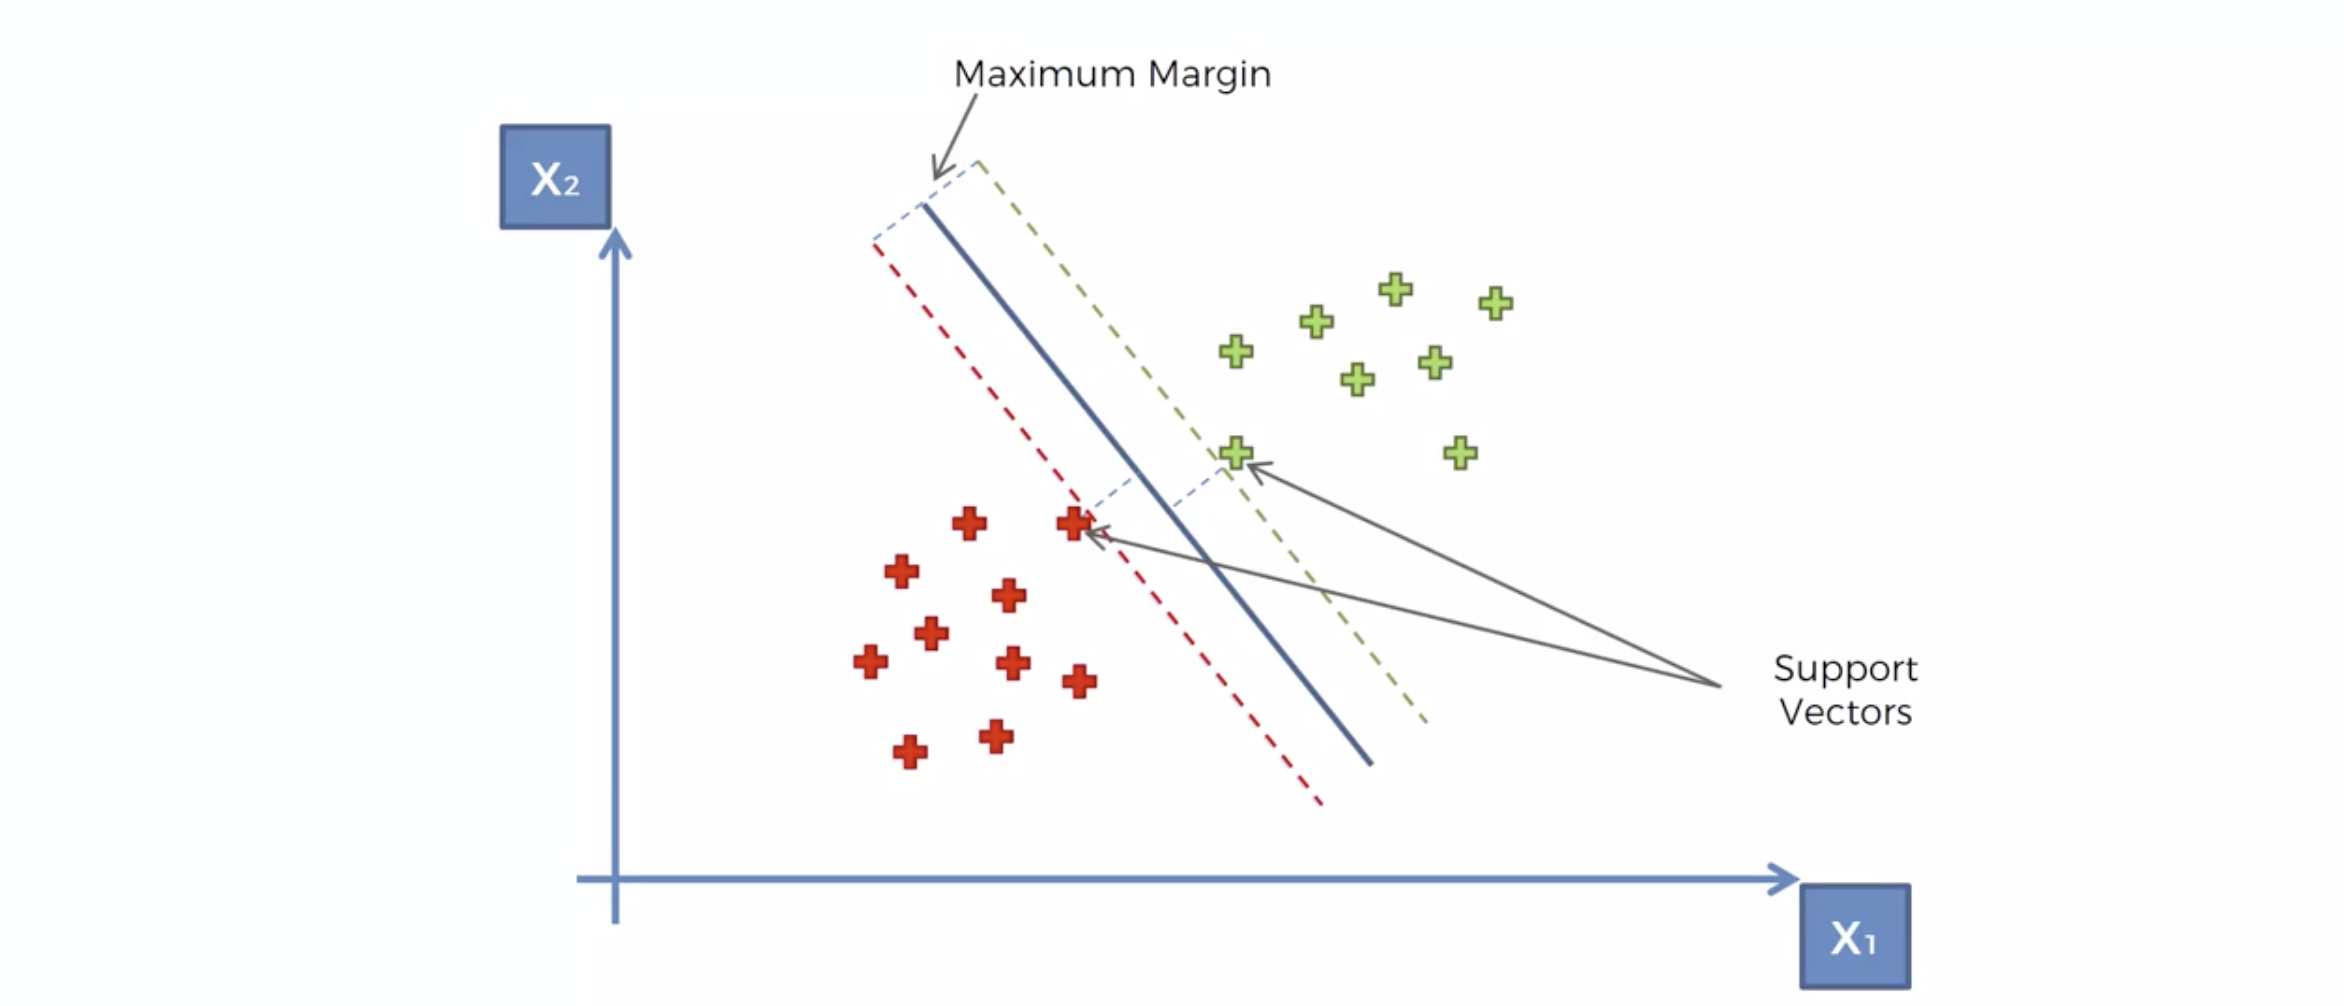

## 분류선을 Maximum Margin Classifer 라고 한다.

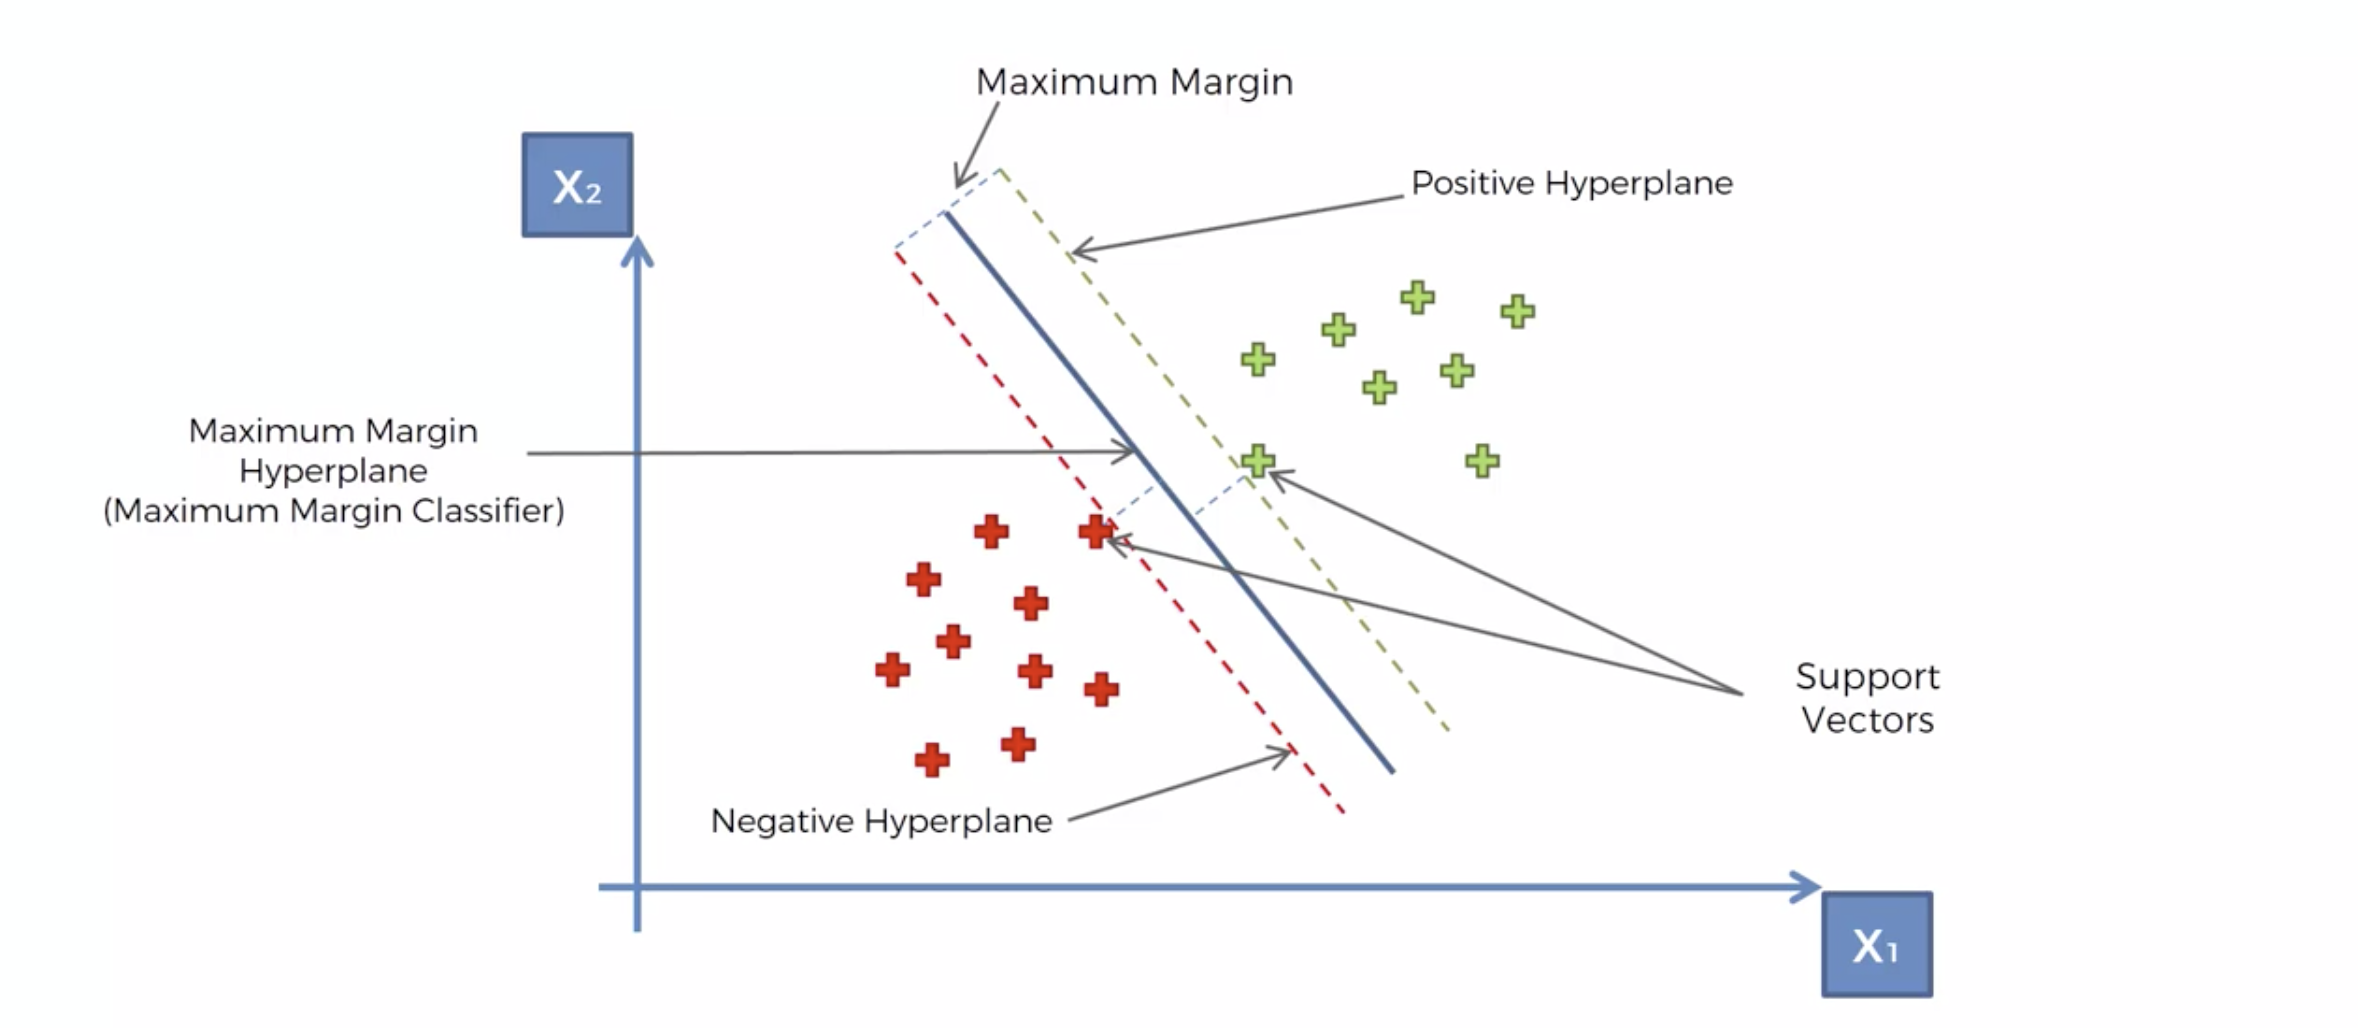

# SVM은 다른 머신러닝 알고리즘과 비교해서 무엇이 특별한가?

## 사과인지 오렌지인지 분석하는 문제

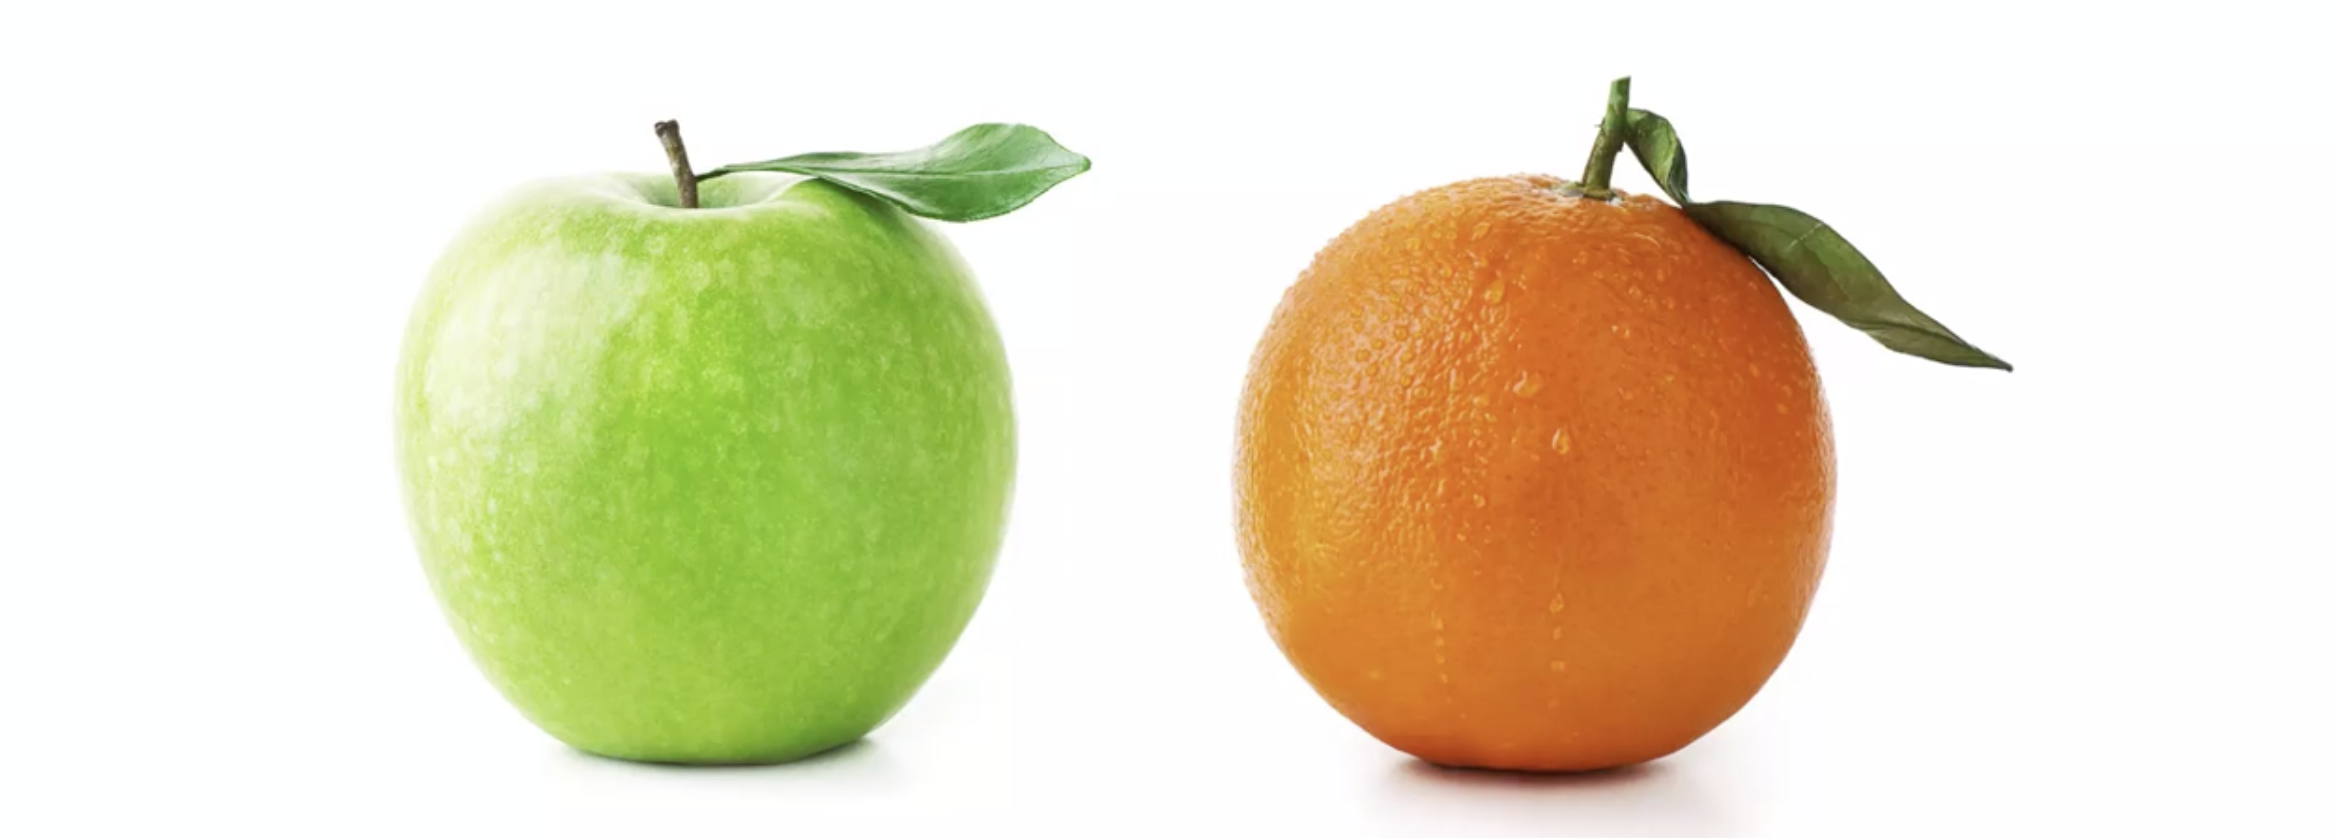

### 일반적인 사과와 오렌지들은, 분류기에서 멀리 분포한다.

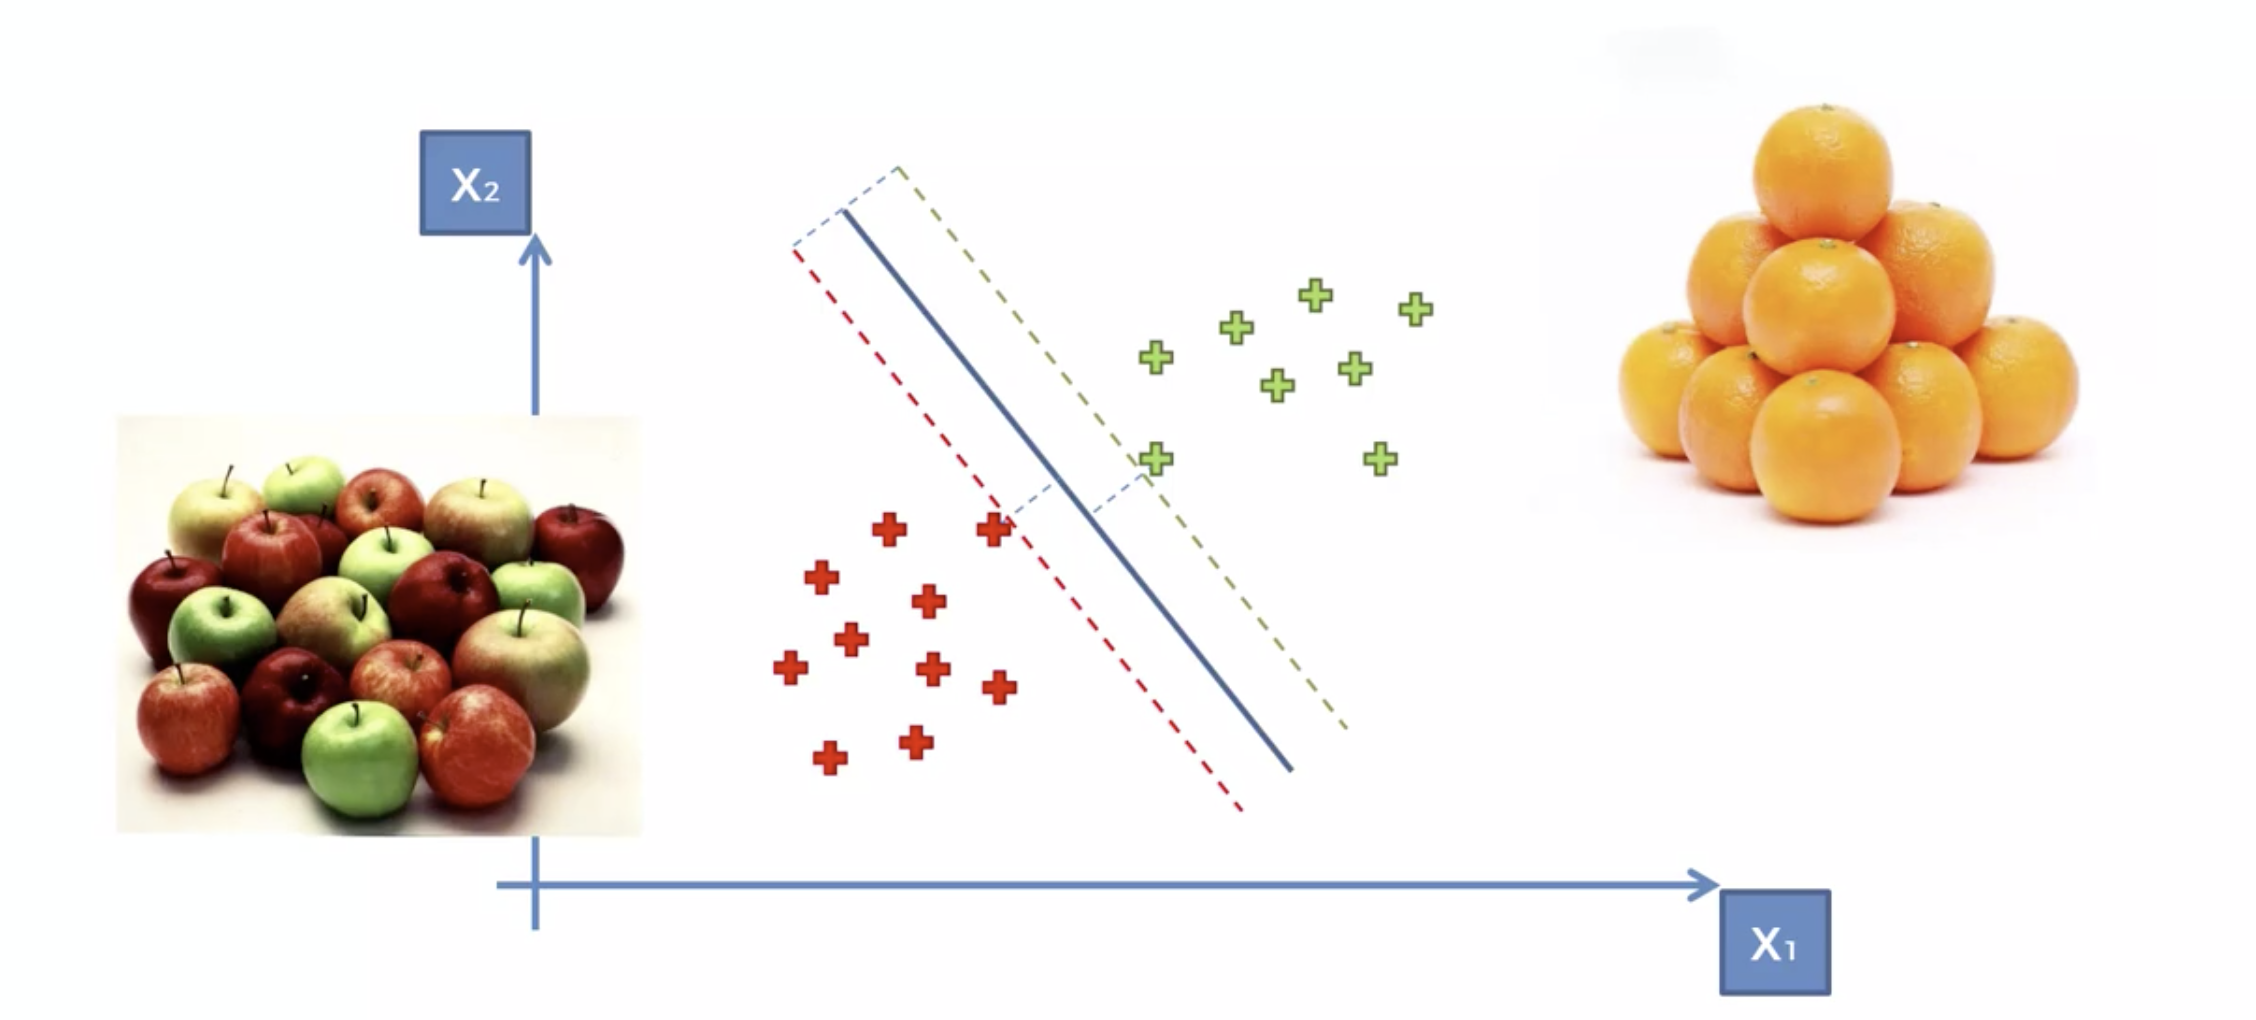

### 정상적이지 않은 것들, 즉 구분하기 힘든 부분에 있는 것들은 분류기 근처에 있게 되며, 

### 이 데이터들이 레이블링 되어 있으므로, Margin을 최대화하여 분류하기 때문에, 특이한 것들까지 잘 분류하는 문제에 SVM 이 최고다.  

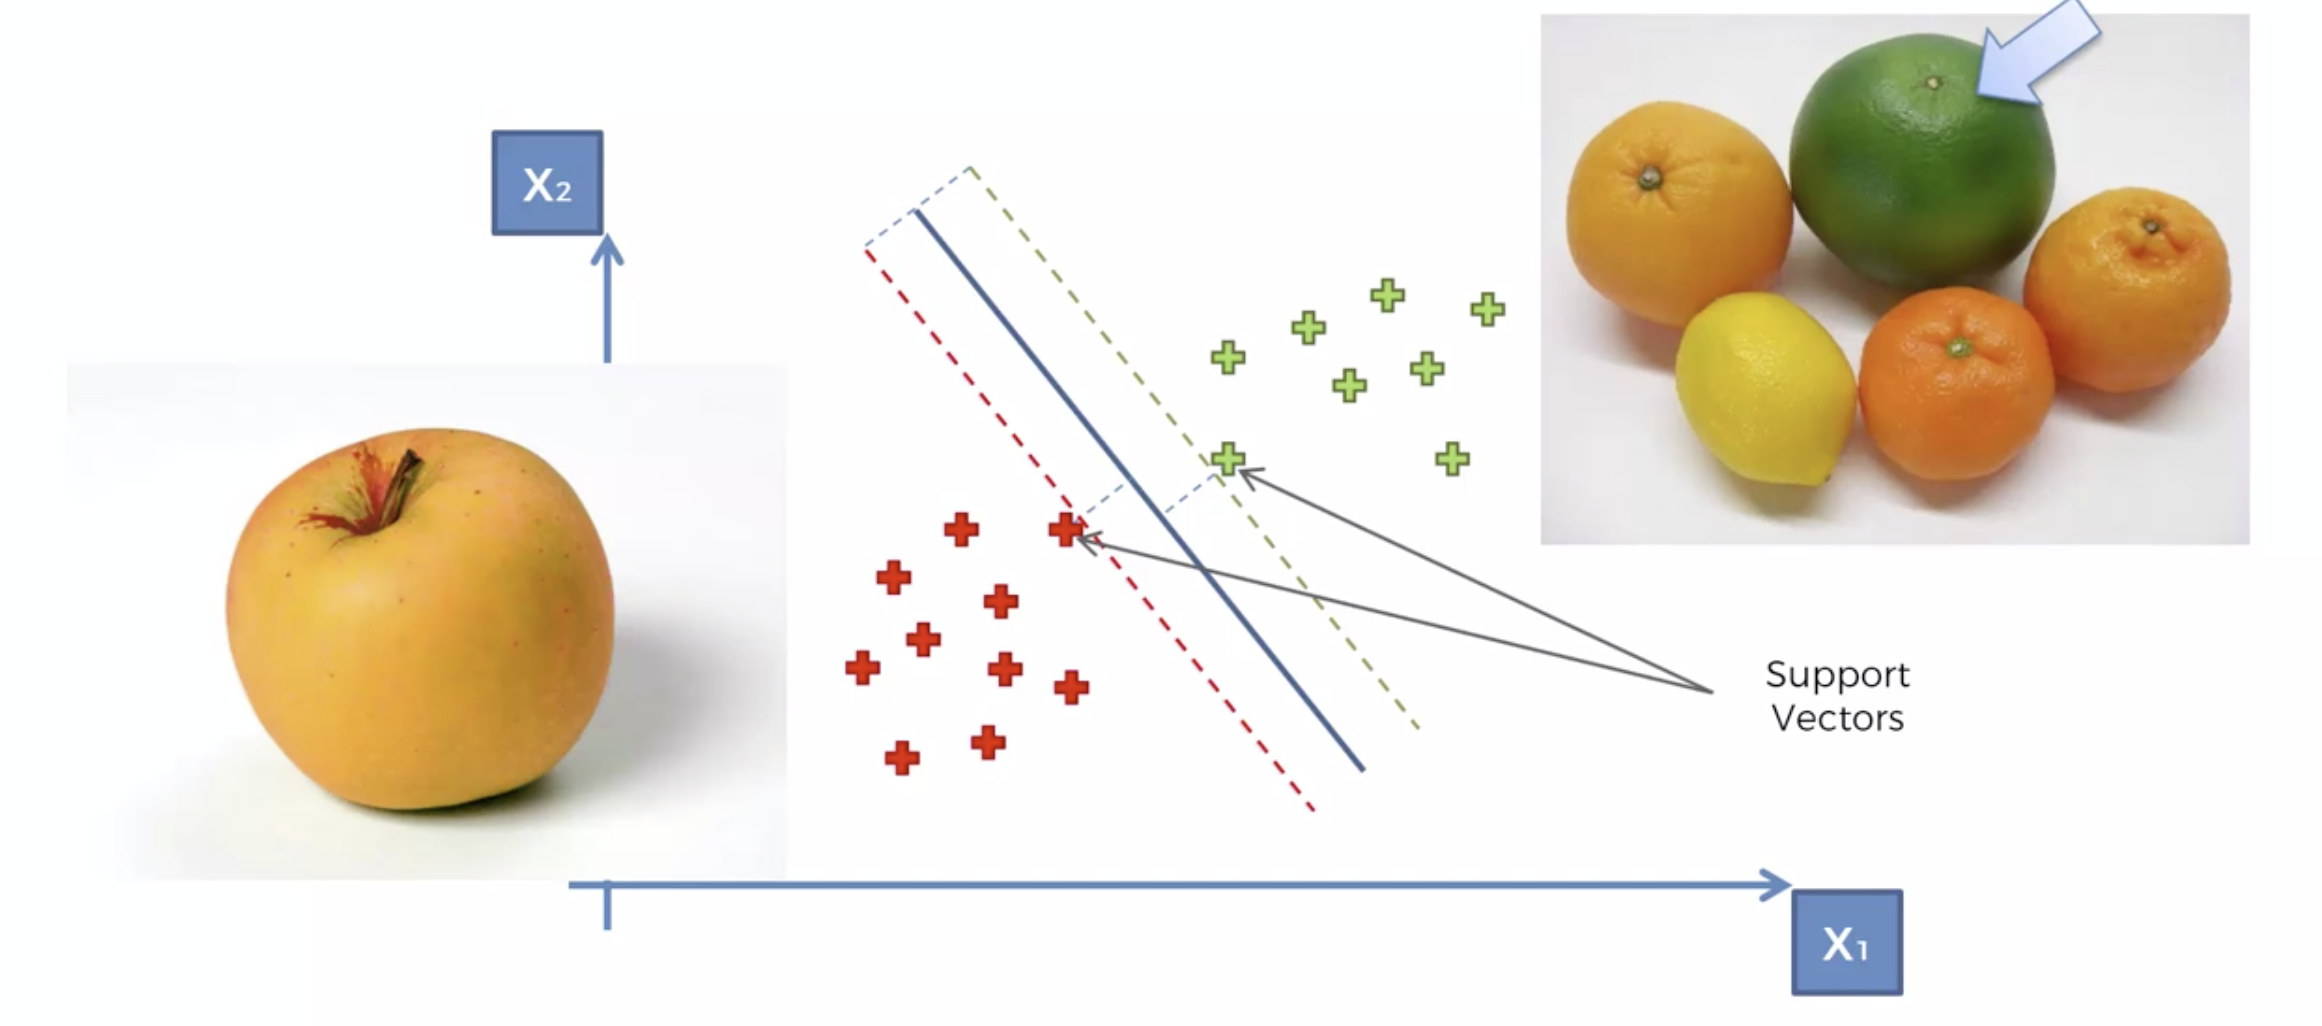

- 딥러닝 나오기 전까지는 정확도가 높아 많이 활용한 모델

In [1]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importing the dataset
df = pd.read_csv('datas_ml/Social_Network_Ads.csv')

In [3]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
y = df['Purchased']

In [5]:
X = df[['Gender', 'Age', 'EstimatedSalary']]

In [6]:
def get_gender(gender):
    if gender == "Male":
        return 0
    else :
        return 1

In [7]:
# X['Gender'].apply(get_gender)
X['Gender'] = X['Gender'].apply(get_gender)

# Feature Scaling

In [8]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
X_scaler = StandardScaler()
X_scaled = X_scaler.fit_transform(X)
X_scaled

array([[-1.02020406, -1.78179743, -1.49004624],
       [-1.02020406, -0.25358736, -1.46068138],
       [ 0.98019606, -1.11320552, -0.78528968],
       ...,
       [ 0.98019606,  1.17910958, -1.46068138],
       [-1.02020406, -0.15807423, -1.07893824],
       [ 0.98019606,  1.08359645, -0.99084367]], shape=(400, 3))

# train, test 데이터 분할

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=7)

In [11]:
X_train.shape, y_train.shape

((300, 3), (300,))

In [12]:
X_test.shape, y_test.shape

((100, 3), (100,))

## 모델 학습

In [13]:
from sklearn.svm import SVC

In [14]:
# 빈 깡통 모델
# 하이퍼 파리미터 : 
classifier = SVC()
# classifier = SVC(kernel='poly')  # 다항식 형태의 곡선 경계,  Polynomial Kernel ('poly')
# classifier = SVC(kernel='rbf')  # 가우시안 형태의 부드러운 경계, default

In [15]:
# 학습
classifier.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [16]:
y_pred = classifier.predict(X_test)
y_pred

array([1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0])

## 테스트 평가

In [17]:
# 정확도
(y_test == y_pred).sum() / len(y_test) * 100

np.float64(90.0)

- 컨퓨전 메트릭스

In [18]:
from sklearn.metrics import confusion_matrix

# confusion_matrix(실제값, 예측값)
confusion_matrix(y_test, y_pred)

array([[63,  5],
       [ 5, 27]])

In [19]:
from sklearn.metrics import classification_report, accuracy_score

# y_test: 실제 라벨, y_pred: 모델 예측 라벨
print("정확도:", accuracy_score(y_test, y_pred))
print("\n[정밀도, 재현율, F1-score 요약 보고서]")
print(classification_report(y_test, y_pred))

정확도: 0.9

[정밀도, 재현율, F1-score 요약 보고서]
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        68
           1       0.84      0.84      0.84        32

    accuracy                           0.90       100
   macro avg       0.89      0.89      0.89       100
weighted avg       0.90      0.90      0.90       100



In [20]:
# macro avg
(0.93+0.84)/2

0.885

In [21]:
# weighted avg
(0.93*68 + 0.84*32)/100

0.9012

- 기본 : 0.9
- 커널 linear : 0.885
- 커널 poly : 0.885
- 커널 rbf : 0.9

In [22]:
X_test

array([[ 0.98019606,  0.41500455,  1.123426  ],
       [-1.02020406, -1.30423178, -0.34481683],
       [ 0.98019606, -0.15807423,  0.15438573],
       [-1.02020406, -0.73115301,  0.50676401],
       [-1.02020406,  0.31949142,  0.50676401],
       [-1.02020406,  1.08359645, -1.22576253],
       [ 0.98019606,  0.98808332,  2.0043717 ],
       [ 0.98019606, -0.0625611 ,  0.03692631],
       [ 0.98019606,  2.03872775,  0.53612887],
       [ 0.98019606, -0.44461362, -0.02180341],
       [ 0.98019606, -1.39974491, -0.63846539],
       [ 0.98019606,  1.84770149, -1.28449224],
       [ 0.98019606, -0.63563988, -1.60750566],
       [-1.02020406,  1.46564897,  0.06629116],
       [ 0.98019606,  0.31949142,  0.30121002],
       [-1.02020406,  2.13424088, -0.81465453],
       [-1.02020406,  0.22397829, -0.31545197],
       [-1.02020406, -0.92217926,  0.27184516],
       [ 0.98019606,  0.41500455,  0.15438573],
       [-1.02020406,  0.98808332,  0.12502088],
       [ 0.98019606, -0.82666613,  0.389

# 일반화

## [Tip]
- 신규 데이터가 있습니다.
- 새로운 사람이 회원가입했는데, 이 사람은 우리물건을 구매할건지 안할건지 예측하세요.
- 연봉은 38700달러이고, 나이는 39세, 남성 입니다.

In [23]:
X.head()

,Gender,Age,EstimatedSalary
0,0,19,19000
1,0,35,20000
2,1,26,43000
3,1,27,57000
4,0,19,76000


1. 데이터 구조 만들기

In [24]:
real_data= [0, 39, 38700]
real_x = np.array(real_data).reshape(-1, 3)

In [25]:
real_x

array([[    0,    39, 38700]])

2. 스케일링하기

In [26]:
# 변환만 해야함, fit은 위에서 했음.
real_x_scaled = X_scaler.transform(real_x)
real_x_scaled

array([[-1.02020406,  0.12846516, -0.91155856]])

3. 예측하기

In [27]:
y_real = classifier.predict(real_x_scaled)
y_real

array([0])

## 모델 저장하기

- 아래 파일 모두 저장해야 함.

In [28]:
import joblib

In [32]:
joblib.dump(X_scaler, 'models/X_scaler.pkl')

['models/X_scaler.pkl']

In [33]:
joblib.dump(classifier, 'models/svm_classifier.pkl')

['models/svm_classifier.pkl']